In [56]:
from sympy import *

r, theta, N, L, y = symbols('r, theta, N, L, y')

y_func = N*sqrt((L/N)**2 - (2*r*sin((theta/N)/2))**2)
y_func

N*sqrt(L**2/N**2 - 4*r**2*sin(theta/(2*N))**2)

In [57]:
sols = solve(Eq(y_func, y), theta)
for sol in sols:
    display(Eq(symbols('theta'),simplify(sol)))

Eq(theta, 2*N*(pi - asin(sqrt(L**2 - y**2)/(2*N*r))))

Eq(theta, 2*N*(asin(sqrt((L - y)*(L + y))/(2*N*r)) + pi))

Eq(theta, -2*N*asin(sqrt((L - y)*(L + y))/(2*N*r)))

Eq(theta, 2*N*asin(sqrt((L - y)*(L + y))/(2*N*r)))

In [83]:
theta_func = sols[3]
theta_func

2*N*asin(sqrt((L - y)*(L + y))/(2*N*r))

In [86]:
limit(theta_func, N, Infinity)

sqrt((L - y)*(L + y))/r

In [59]:
subs_dict = {
    r:0.001,
    L:0.1,
    N:100,
}

y_func.subs(subs_dict).subs(theta, 100).n()

0.0283909513289498

In [60]:
theta_func.subs(subs_dict).subs(y, 0.0283909513289498).n()

100.000000000000

In [70]:
G1 = diff(theta_func, y)
G1

-y*sqrt((L - y)*(L + y))/(r*sqrt(1 - (L - y)*(L + y)/(4*N**2*r**2))*(L - y)*(L + y))

In [71]:
simplify(G1)

-2*y/(r*sqrt((-L**2 + 4*N**2*r**2 + y**2)/(N**2*r**2))*sqrt(L**2 - y**2))

In [78]:
from sympy.core.numbers import Infinity

simplify(limit(G1, N, Infinity))

-y/(r*sqrt(L**2 - y**2))

In [81]:
G = simplify(1/diff(y_func, theta))
G

-sqrt(L**2/N**2 + 2*r**2*cos(theta/N) - 2*r**2)/(r**2*sin(theta/N))

In [82]:
simplify(limit(G, N, Infinity))

-sqrt(L**2 - r**2*theta**2)/(r**2*theta)

In [25]:
from sympy import latex
print(latex(G))


- \frac{\sqrt{\frac{L^{2}}{N^{2}} + 2 r^{2} \cos{\left(\frac{\theta}{N} \right)} - 2 r^{2}}}{r^{2} \sin{\left(\frac{\theta}{N} \right)}}


ValueError: x and y must have same first dimension, but have shapes (99,) and (0,)

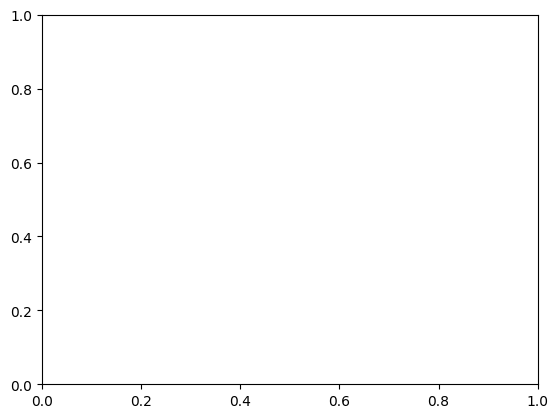

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Define values for r, theta, and L for the plot
r_val = 1
theta_val = np.pi
L_val = 1

Ns = np.arange(10, 1000, 10)
G_vals = []

for N_val in Ns:
    G_num = G_inv.subs({r: r_val, theta: theta_val, N: N_val, L: L_val}).evalf()
    # Only append if G_num is not complex
    if not G_num.is_real:
        continue
    G_vals.append(G_num)

plt.plot(Ns, G_vals)
plt.xlabel('N')
plt.ylabel('G')
plt.title('Plot of G vs N')
plt.grid(True)
plt.show()


In [4]:
from sympy.core.numbers import Infinity


limit(G_inv, N, 9999)

r**2*sin(theta/9999)/sqrt(L**2 + 2*r**2*cos(theta/9999) - 2*r**2)